In [2]:
! pip install shap

Mean Squared Error: 2952.01


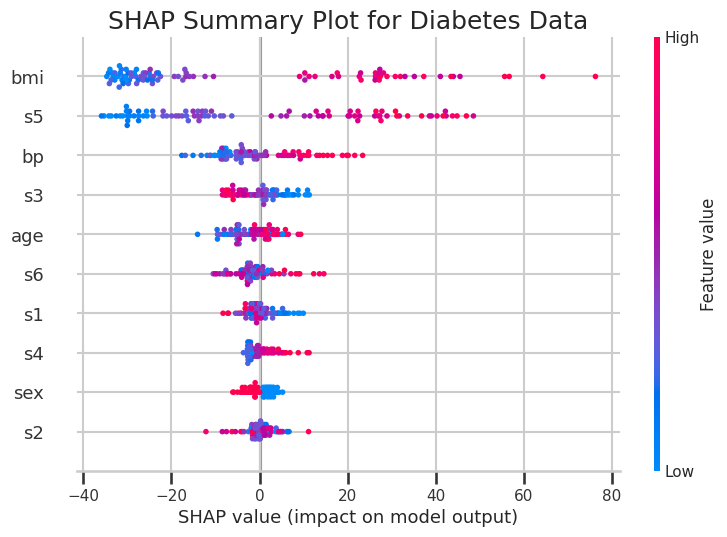

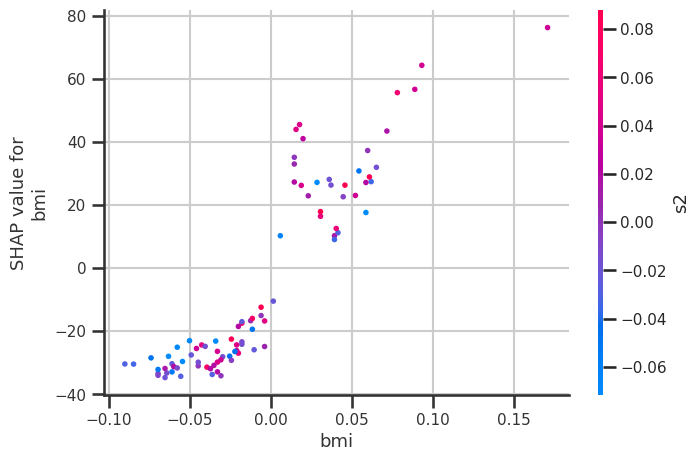

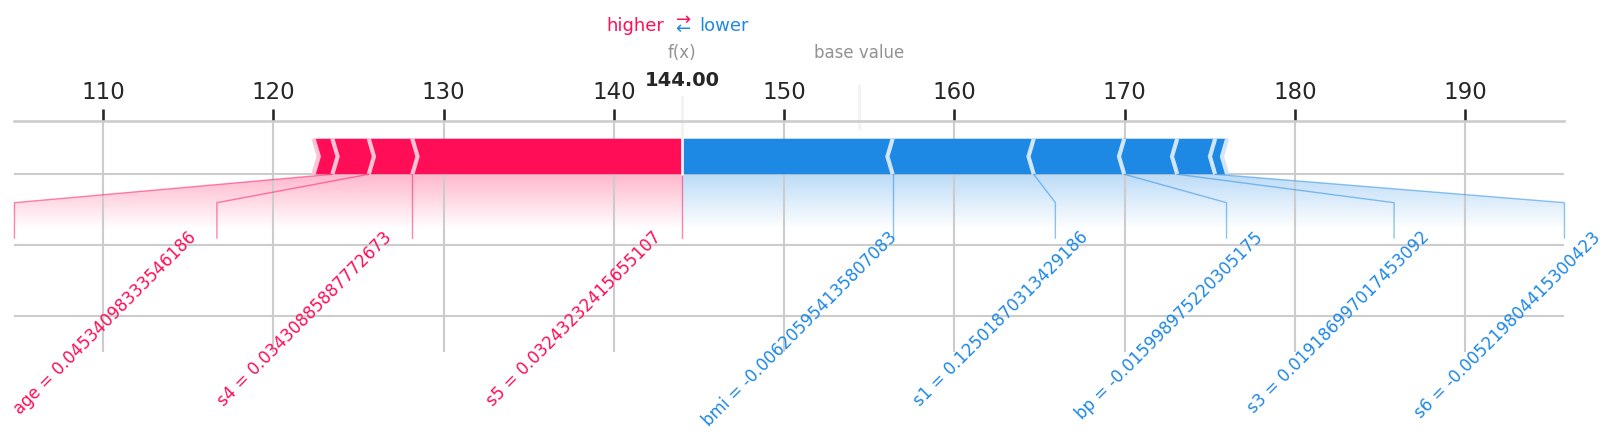

In [20]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import shap
import matplotlib.pyplot as plt

# Step 1: Load Diabetes Dataset
diabetes_data = load_diabetes()
X = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
y = diabetes_data.target

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Step 4: Explainability with SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot for Diabetes Data")
plt.show()

# SHAP Dependence Plot (example: 'bmi' - Body Mass Index)
shap.dependence_plot('bmi', shap_values, X_test)

# Select a specific test instance
i = 0  # Index of the instance to explain
shap.force_plot(
    explainer.expected_value[0],
    shap_values[i],
    X_test.iloc[i],
    matplotlib=True,
    text_rotation=45
)


SHAP summary plot provides a global view of feature importance and how each feature influences predictions:

* Y-axis: Features sorted by importance (highest at the top).
* X-axis: SHAP values (impact on model output).
* Color: Represents the feature value (red for high values, blue for low values).

Interpretation:

Feature importance: bmi has the highest overall importance in predicting diabetes progression, followed by s5 and bp.
Direction of impact:
High values of bmi (red) have a positive impact on predictions (increase the target value).
Low values of bmi (blue) have a negative impact.
Feature interactions: The spread in SHAP values for each feature indicates how its impact varies across different data points.


---



SHAP dependence plot for the feature bmi (Body Mass Index) provides the following insights:

* X-axis (bmi): The actual values of the bmi feature.
* Y-axis (SHAP value for bmi): The contribution of bmi to the model's prediction.
* Color (s2): The color represents the values of another feature (s2), showing interactions between bmi and s2.

Interpretation:

Higher bmi values generally lead to higher SHAP values, indicating a positive relationship between bmi and the target (diabetes progression).
The interaction with s2 shows that its value further modulates the contribution of bmi (e.g., higher s2 values tend to amplify the SHAP values for high bmi).

In [4]:
! pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=6ece2e9b84bc3f8f795c173c28a706e9b880ab8fe2689d981e06e9a56e1dfbc1
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


In [16]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lime.lime_tabular
import matplotlib.pyplot as plt

# Step 1: Load Diabetes Dataset
diabetes_data = load_diabetes()
X = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
y = diabetes_data.target
feature_names = X.columns

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Step 4: Explainability with LIME
# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    mode="regression",
    verbose=True
)

# Choose a specific instance from the test set to explain
i = 10  # Index of the instance to explain
instance = X_test.iloc[i].values.reshape(1, -1)

# Generate explanation
exp = explainer.explain_instance(
    data_row=instance.flatten(),
    predict_fn=model.predict
)

# Display explanation in text form
print("\nLIME Explanation for Instance:")
for feature, value in exp.as_list():
    print(f"{feature}: {value:.3f}")

# Generate and display the force plot-like visualization
exp.show_in_notebook(show_table=True)


Mean Squared Error: 2952.01
Intercept 179.93750771149965
Prediction_local [99.57986332]
Right: 103.27

LIME Explanation for Instance:
bmi <= -0.03: -35.549
-0.03 < s5 <= -0.00: -19.859
s3 > 0.03: -8.939
-0.04 < bp <= -0.01: -6.428
age <= -0.03: -4.825
s1 > 0.03: -3.640
sex <= -0.04: 3.555
s2 > 0.03: -3.461
-0.04 < s4 <= -0.00: -0.644
s6 <= -0.03: -0.569


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [1]:
!pip install alibi

Feature Importance:
  Feature  Importance
2     bmi    0.355469
8      s5    0.230957
3      bp    0.088408
9      s6    0.071329
0     age    0.058642
5      s2    0.057227
4      s1    0.052784
6      s3    0.051339
7      s4    0.024213
1     sex    0.009633


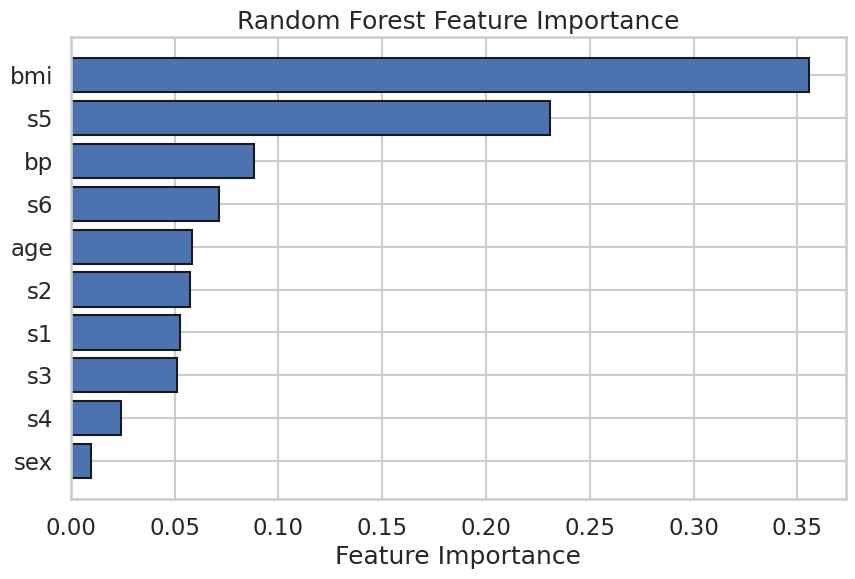

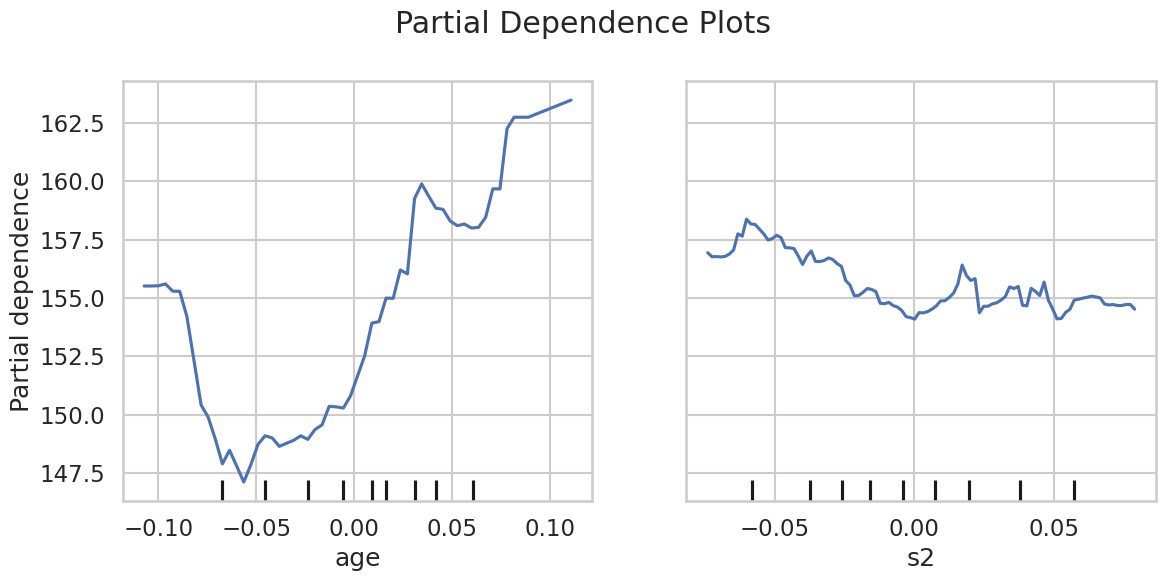

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does

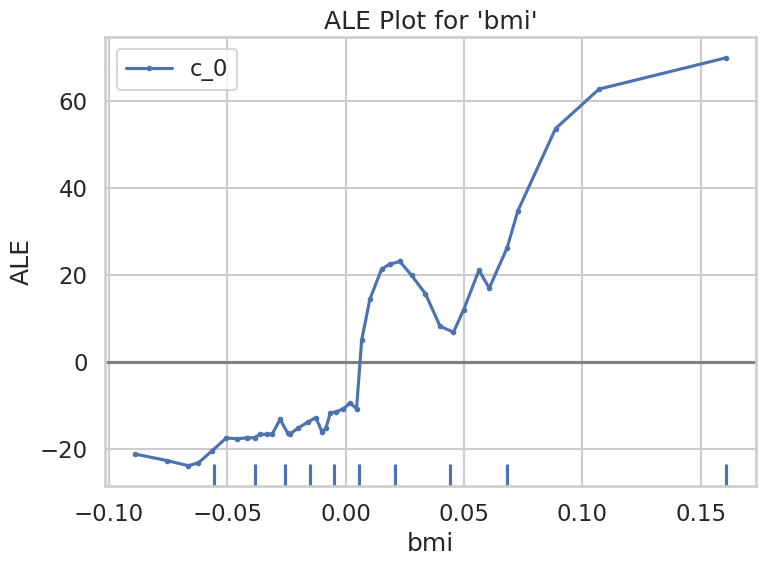

Permutation Importance:
  Feature   Importance      StdDev
8      s5  1381.006632  291.040997
2     bmi  1238.791080  367.176871
3      bp   101.500483  166.337687
1     sex    96.869458   31.060673
9      s6    89.459706   91.528290
0     age    33.080634  104.722520
7      s4     3.332549   42.635420
5      s2   -15.141029   66.972626
6      s3   -53.612171   60.619802
4      s1   -75.813138   73.555906


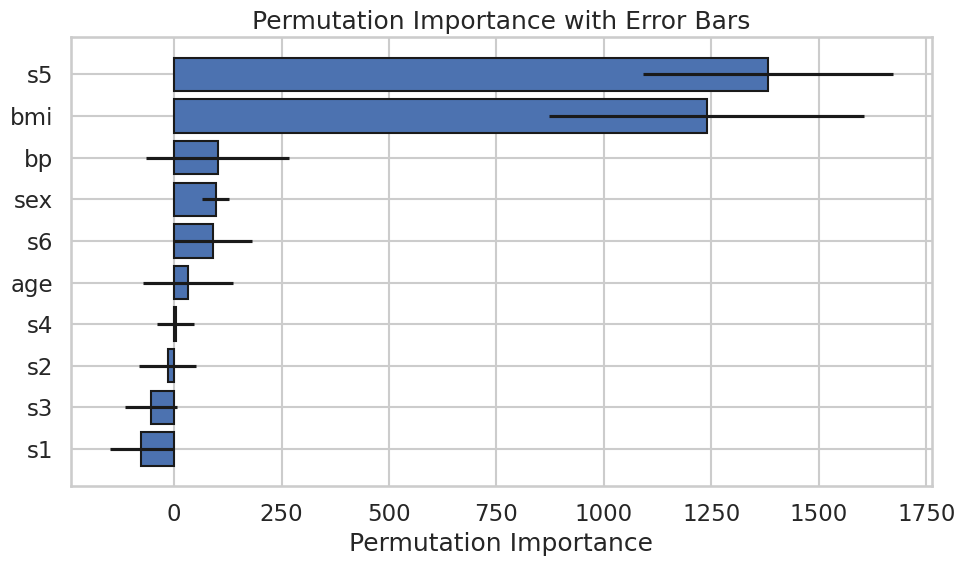

In [17]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import matplotlib.pyplot as plt
from alibi.explainers import ALE, plot_ale

# Step 1: Load Diabetes Dataset
diabetes_data = load_diabetes()
X = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
y = diabetes_data.target
feature_names = X.columns

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 4: Feature Importance from Random Forest
feature_importances = model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

print("Feature Importance:")
print(importance_df)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], edgecolor='k')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Step 5: Partial Dependence Plots (PDP)
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    model, X_train, features=[0, 5], feature_names=feature_names, ax=ax
)
plt.suptitle("Partial Dependence Plots")
plt.tight_layout()
plt.show()

# Step 6: Accumulated Local Effects (ALE)
ale_explainer = ALE(model.predict, feature_names=feature_names)
ale_exp = ale_explainer.explain(X_train.values)

# ALE Plot for 'bmi'
fig, ax = plt.subplots(figsize=(8, 6))
plot_ale(ale_exp, features=["bmi"], ax=ax)
plt.title("ALE Plot for 'bmi'")
plt.tight_layout()
plt.show()

# Step 7: Permutation Importance
perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=30, random_state=42, scoring="neg_mean_squared_error"
)

# Convert permutation importance to DataFrame
perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_importance.importances_mean,
    "StdDev": perm_importance.importances_std
}).sort_values(by="Importance", ascending=False)

print("Permutation Importance:")
print(perm_df)

# Plot Permutation Importance
plt.figure(figsize=(10, 6))
plt.barh(perm_df["Feature"], perm_df["Importance"], xerr=perm_df["StdDev"], edgecolor='k')
plt.xlabel("Permutation Importance")
plt.title("Permutation Importance with Error Bars")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Key Components of the ALE Plot

## X-axis (`bmi`):
- Represents the values of the `bmi` feature (Body Mass Index) in the dataset.

## Y-axis (`ALE`):
- Shows the accumulated local effect of the `bmi` feature on the model's prediction. This indicates how the model's predictions change as the value of `bmi` changes.

## Zero Line:
- The horizontal line at `ALE = 0` represents the baseline prediction of the model (no influence from `bmi`).
  - Positive ALE values mean the feature increases the model's prediction.
  - Negative ALE values mean the feature decreases the model's prediction.

## Vertical Ticks:
- Represent the distribution of `bmi` values in the training data.
  - Sparse ticks indicate less common `bmi` values, while dense regions indicate frequently observed values.

---

# Interpreting the Plot

## Impact of `bmi` on Predictions:
- For `bmi` values below approximately `-0.05`, the ALE is negative, meaning these values decrease the model's prediction compared to the baseline.
- Between `-0.05` and `0.05`, the ALE fluctuates around 0, showing a mix of slightly positive and negative impacts on the predictions.
- For `bmi` values greater than `0.05`, the ALE increases sharply, indicating that higher `bmi` values significantly increase the predicted diabetes progression.

## Nonlinear Relationships:
- The curve's shape suggests a nonlinear relationship between `bmi` and the target:
  - Initially, the effect of increasing `bmi` is small and fluctuates.
  - After a certain threshold (`bmi > 0.05`), the effect becomes strongly positive and grows sharply.

## Feature Distribution:
- The vertical ticks show that most data points fall between `-0.05` and `0.1`, meaning the model has more reliable estimates in this range.
- Sparse ticks in extreme values (e.g., `bmi < -0.1` or `bmi > 0.15`) suggest these regions may have higher uncertainty due to less data.

---

# Takeaways

## Low `bmi` Values:
- Tend to reduce predicted diabetes progression compared to the baseline.

## Moderate `bmi` Values:
- Have minimal impact on predictions, fluctuating slightly around the baseline.

## High `bmi` Values:
- Significantly increase predicted diabetes progression, indicating that `bmi` is an important predictor in the model for individuals with high BMI.

---

# Using This Insight

## Feature Importance:
- The sharp increase at higher `bmi` values highlights this feature's strong influence on predictions, especially in the upper range.

## Model Trust:
- The dense tick marks in the middle range suggest the model is more trustworthy here due to better data coverage.
- Sparse regions may require additional data or caution in interpretation.

## Target Interventions:
- For applications like healthcare, this insight shows that higher BMI is strongly associated with increased diabetes progression, suggesting interventions might focus on reducing BMI for at-risk individuals.


In [18]:
! pip install interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 19.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.9/778.9 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.5/254.5 kB 12.8 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=40

In [19]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

# Step 1: Load Diabetes Dataset
diabetes_data = load_diabetes()
X = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
y = diabetes_data.target
feature_names = X.columns

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Explainable Boosting Machine (EBM)
# EBM is a GAM-based algorithm from the `interpret` package
ebm = ExplainableBoostingRegressor(random_state=42)
ebm.fit(X_train, y_train)

# Step 4: Evaluate the Model
y_pred = ebm.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (EBM): {mse:.2f}")

# Step 5: Global Explanation
# The global explanation shows how each feature contributes to predictions
global_explanation = ebm.explain_global()

# Show the global explanation in an interactive visualization
show(global_explanation)

# Step 6: Local Explanation for a Specific Instance
# Choose a specific instance to explain
i = 10
local_explanation = ebm.explain_local(X_test.iloc[i:i+1], y_test[i:i+1])

# Show the local explanation in an interactive visualization
show(local_explanation)


Mean Squared Error (EBM): 2775.02
